# Filtragem Espacial, Remoção de Ruído e Detecção de Bordas — Cartas de Baralho

## Objetivo
Aplicar técnicas de filtragem espacial para suavização, remoção de ruído e detecção de bordas nas
imagens reais coletadas para o mini dataset de cartas de baralho (Copas x Espadas), analisando
criticamente o tipo de degradação presente em cada imagem e justificando tecnicamente a escolha do
filtro mais adequado, com base nos fundamentos teóricos de pré-processamento de imagens.

Este notebook dá continuidade ao dataset construído em `settingData.ipynb` (aquisição com Samsung
Galaxy A33, 4000x3000, condições reais de iluminação e distância).

**Como executar:** o notebook assume que é executado a partir da pasta `notebook/` do repositório,
com o dataset em `../data/hearts` e `../data/spades` (mesma estrutura de `settingData.ipynb`). No
Google Colab, clone o repositório ou faça upload da pasta `data` mantendo essa estrutura relativa.

## Configuração inicial

In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

DATA_DIR = "../data"
RESIZE_WIDTH = 900  # reduz a imagem para acelerar o processamento, mantendo ruído/textura visíveis


def load_resized(path, width=RESIZE_WIDTH):
    img_bgr = cv2.imread(path)
    if img_bgr is None:
        raise FileNotFoundError(f"Não foi possível abrir {path}")
    h, w = img_bgr.shape[:2]
    scale = width / w
    img_bgr = cv2.resize(img_bgr, (width, int(h * scale)))
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    return img_rgb, img_gray


def show_grid(images, titles, cols=4, figsize_scale=3.6, suptitle=None):
    n = len(images)
    rows = int(np.ceil(n / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(figsize_scale * cols, figsize_scale * rows))
    axes = np.array(axes).reshape(-1)
    for i, ax in enumerate(axes):
        if i < n:
            cmap = "gray" if images[i].ndim == 2 else None
            ax.imshow(images[i], cmap=cmap)
            ax.set_title(titles[i], fontsize=10)
        ax.axis("off")
    if suptitle:
        fig.suptitle(suptitle, fontsize=14)
    plt.tight_layout()
    plt.show()


def normalize_u8(img):
    img = np.abs(img)
    return cv2.normalize(img, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)


def laplacian_energy(gray):
    """Variância do Laplaciano: medida padrão de nitidez/energia de borda (quanto maior, mais detalhe/borda preservado)."""
    return float(cv2.Laplacian(gray, cv2.CV_64F).var())


## Parte 1 — Seleção das imagens

Critério de seleção: imagens do dataset com granulação, variações aleatórias de intensidade,
baixa qualidade visual, compressão visível ou ruído perceptível — todas capturadas em condições de
pouca luz ou alto contraste, que são as principais fontes de degradação neste dataset.

| # | Imagem | Classe | Degradação observada | Hipótese sobre a origem do ruído |
|---|--------|--------|------------------------|-----------------------------------|
| 1 | `a_hearts.jpeg` | A — Copas | Forte contraluz: a carta fica subexposta/quase em silhueta contra o fundo muito claro (grade/rua), com ruído visível nas regiões escuras e risco de clipping nas áreas claras | Cena de alto contraste dinâmico faz a câmera elevar o ganho (ISO) na região escura para tentar recuperar detalhe da carta, amplificando o ruído eletrônico do sensor justamente nas sombras |
| 2 | `4_hearts.jpeg` | A — Copas | Ambiente interno com pouca luz, granulação perceptível no fundo escuro e leve perda de nitidez na carta | Baixa luminância ambiente força ISO mais alto e/ou tempo de exposição maior, aumentando o ruído de sensor e a chance de pequeno borrão por movimento da mão que segura a carta |
| 3 | `a_spade.jpeg` | B — Espadas | Cena muito escura, iluminada principalmente pela luz do teclado/monitor ao fundo; grão evidente no fundo e leve desfoque na carta | Iluminação artificial muito fraca exige ganho (ISO) muito alto, principal causa de ruído granular tipo sal-e-pimenta/gaussiano em sensores de celular |
| 4 | `6_spade.jpeg` | B — Espadas | Fundo escuro (mapa impresso) com granulação visível, mesmo com a carta razoavelmente bem exposta | Mesma causa da imagem anterior — pouca luz ambiente leva a maior ganho do sensor, tornando o ruído mais perceptível nas regiões de baixa luminância do fundo |

Essas quatro imagens cobrem os dois principais tipos de degradação do dataset: **ruído por baixa
luminância/ISO alto** (grão no fundo escuro) e **ruído por alto contraste/contraluz** (clipping e
grão nas sombras).

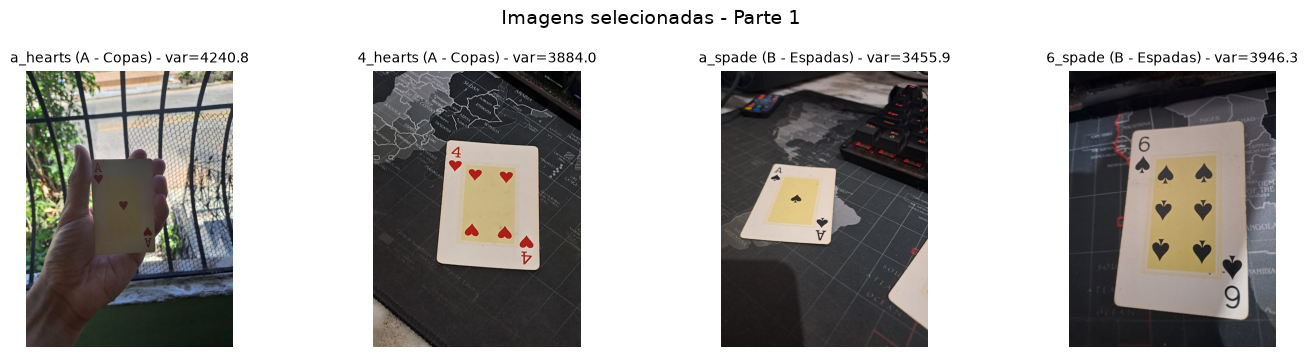

In [2]:
SELECTED = {
    "a_hearts": {"path": f"{DATA_DIR}/hearts/a_hearts.jpeg", "classe": "A - Copas"},
    "4_hearts": {"path": f"{DATA_DIR}/hearts/4_hearts.jpeg", "classe": "A - Copas"},
    "a_spade":  {"path": f"{DATA_DIR}/spades/a_spade.jpeg",  "classe": "B - Espadas"},
    "6_spade":  {"path": f"{DATA_DIR}/spades/6_spade.jpeg",  "classe": "B - Espadas"},
}

for key, meta in SELECTED.items():
    rgb, gray = load_resized(meta["path"])
    meta["rgb"] = rgb
    meta["gray"] = gray
    meta["var_original"] = float(np.var(gray))

show_grid(
    [SELECTED[k]["rgb"] for k in SELECTED],
    [f"{k} ({SELECTED[k]['classe']}) - var={SELECTED[k]['var_original']:.1f}" for k in SELECTED],
    cols=4,
    suptitle="Imagens selecionadas - Parte 1",
)


## Parte 2 — Aplicação de filtros de suavização

Para cada imagem selecionada, aplicamos:

- **Filtro da Média** — kernel 3×3 e 5×5 (`cv2.blur`)
- **Filtro Gaussiano** — σ = 1 e σ = 3 (`cv2.GaussianBlur`)
- **Filtro da Mediana** — kernel 3×3 e 5×5 (`cv2.medianBlur`)

Como métricas objetivas de comparação, usamos:

- **Variância dos níveis de cinza** — indicador de quanto ruído/textura de alta frequência restou na
  imagem (filtros mais agressivos reduzem mais a variância).
- **Energia de borda (variância do Laplaciano)** — indicador de nitidez/quanto de estrutura de borda
  foi preservada (quanto maior, menos a imagem foi borrada).

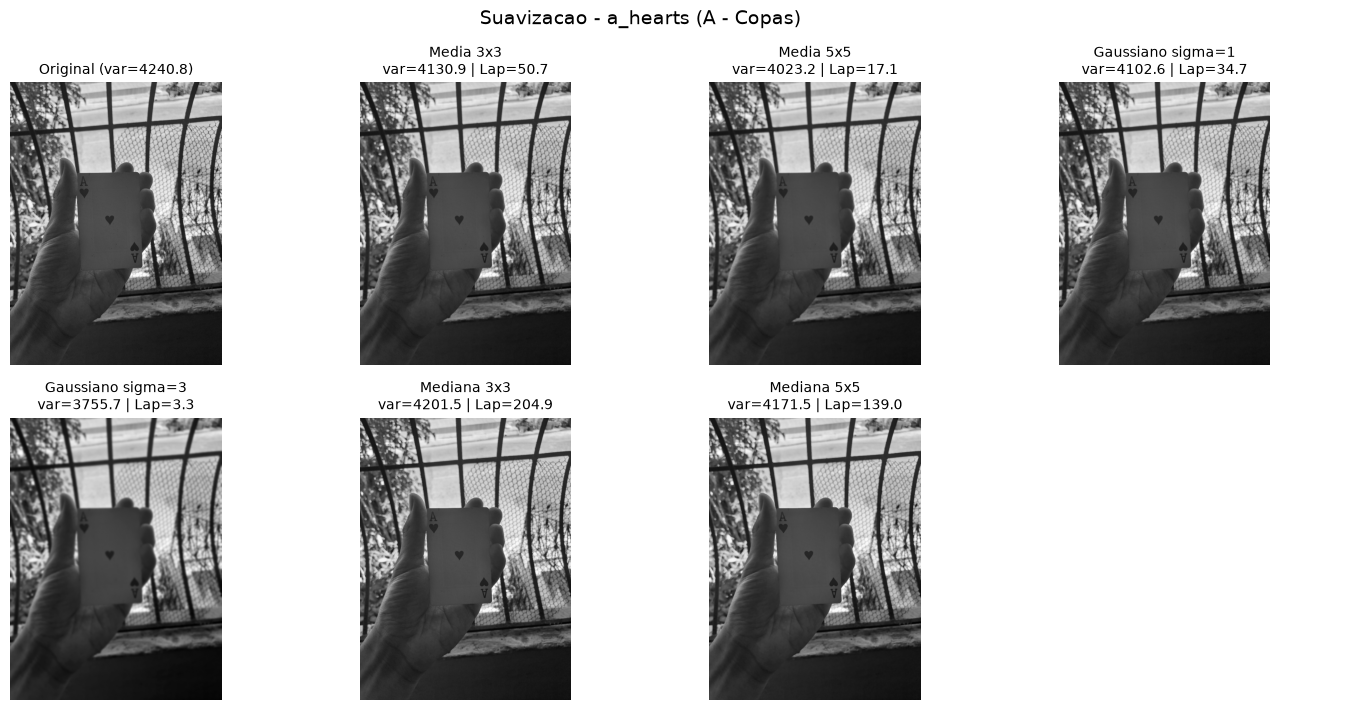

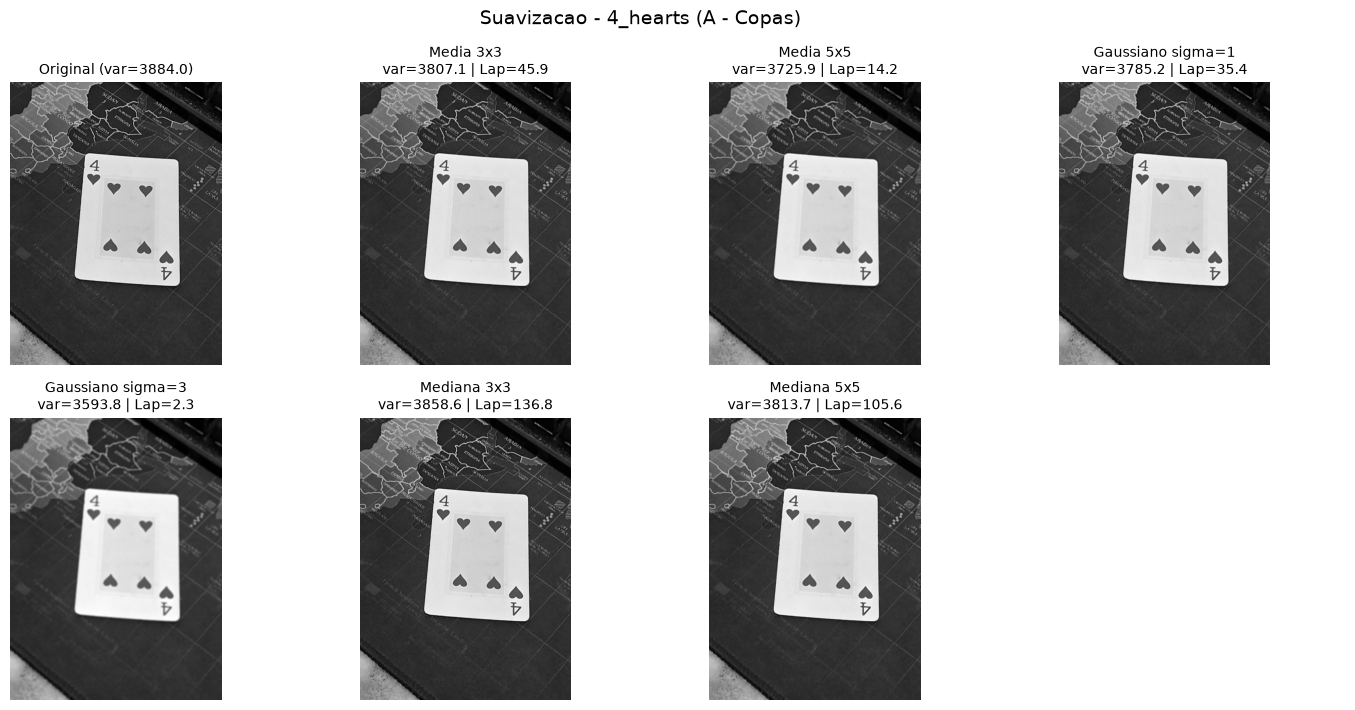

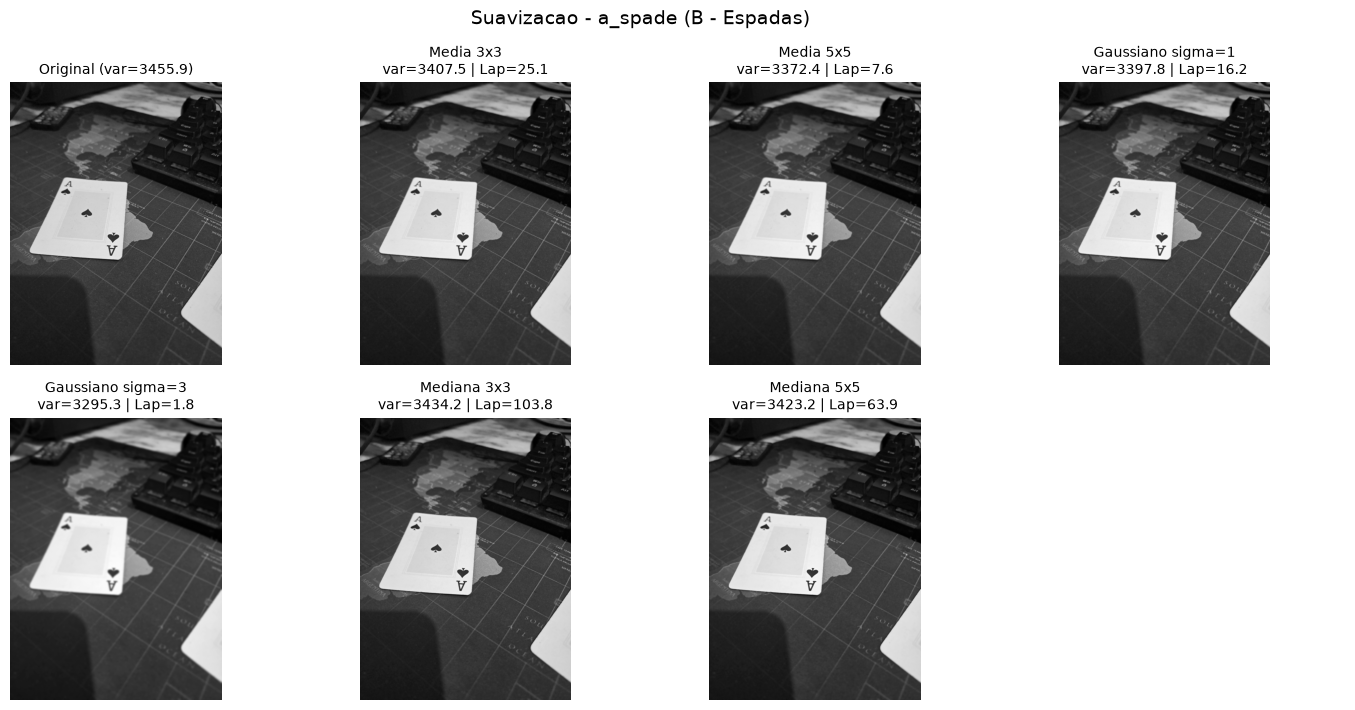

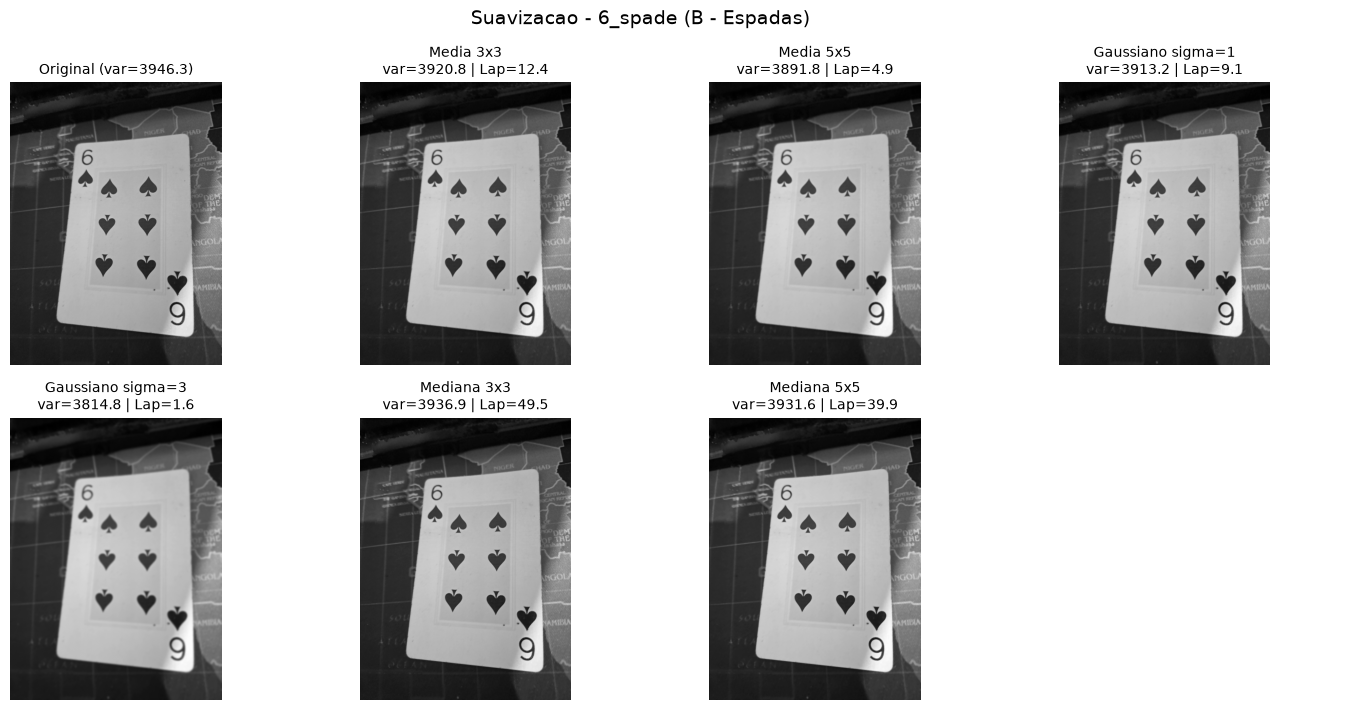

In [3]:
def apply_smoothing_filters(gray):
    return {
        "Media 3x3": cv2.blur(gray, (3, 3)),
        "Media 5x5": cv2.blur(gray, (5, 5)),
        "Gaussiano sigma=1": cv2.GaussianBlur(gray, (0, 0), sigmaX=1),
        "Gaussiano sigma=3": cv2.GaussianBlur(gray, (0, 0), sigmaX=3),
        "Mediana 3x3": cv2.medianBlur(gray, 3),
        "Mediana 5x5": cv2.medianBlur(gray, 5),
    }


smoothing_results = {}  # key -> {nome_filtro: {"img", "var", "edge_energy"}}

for key, meta in SELECTED.items():
    gray = meta["gray"]
    filtered = apply_smoothing_filters(gray)

    stats = {}
    for name, img in filtered.items():
        stats[name] = {
            "img": img,
            "var": float(np.var(img)),
            "edge_energy": laplacian_energy(img),
        }
    smoothing_results[key] = stats

    imgs = [gray] + [stats[n]["img"] for n in filtered]
    titles = [f"Original (var={meta['var_original']:.1f})"] + [
        f"{n}\nvar={stats[n]['var']:.1f} | Lap={stats[n]['edge_energy']:.1f}" for n in filtered
    ]
    show_grid(imgs, titles, cols=4, suptitle=f"Suavizacao - {key} ({meta['classe']})")


In [4]:
for key, meta in SELECTED.items():
    stats = smoothing_results[key]
    var_orig = meta["var_original"]

    mais_reduziu_ruido = min(stats, key=lambda n: stats[n]["var"])
    melhor_preservou_bordas = max(stats, key=lambda n: stats[n]["edge_energy"])

    linhas = "\n".join(
        f"| {n} | {stats[n]['var']:.1f} | {100 * (var_orig - stats[n]['var']) / var_orig:.1f}% | {stats[n]['edge_energy']:.1f} |"
        for n in stats
    )

    display(Markdown(f"""
### Análise quantitativa — `{key}` ({meta['classe']})

Variância original (nível de ruído/textura de alta frequência): **{var_orig:.1f}**

| Filtro | Variância pós-filtro | Redução de variância | Energia de borda (Laplaciano) |
|---|---|---|---|
{linhas}

- **Filtro que mais reduziu o ruído (menor variância): `{mais_reduziu_ruido}`**
- **Filtro que melhor preservou as bordas (maior energia de Laplaciano): `{melhor_preservou_bordas}`**

**Leitura teórica:** kernels maiores (5x5) reduzem mais a variância que os 3x3 equivalentes, à custa
de borrar mais as bordas (menor energia de Laplaciano) — quanto maior o kernel, mais vizinhos de
regiões distintas (carta/fundo) são misturados na mesma janela. O filtro da média pondera todos os
vizinhos igualmente e tende a borrar bordas de forma mais agressiva que o Gaussiano de suporte
equivalente, já que o Gaussiano dá menos peso aos pixels mais distantes do centro. A mediana, por ser
um filtro não linear baseado em estatística de ordem (e não em média ponderada), tende a remover bem
ruído impulsivo/granulação sem borrar tanto as bordas — por isso costuma apresentar a melhor energia
de borda entre os filtros testados, mesmo reduzindo bem a variância.
"""))



### Análise quantitativa — `a_hearts` (A - Copas)

Variância original (nível de ruído/textura de alta frequência): **4240.8**

| Filtro | Variância pós-filtro | Redução de variância | Energia de borda (Laplaciano) |
|---|---|---|---|
| Media 3x3 | 4130.9 | 2.6% | 50.7 |
| Media 5x5 | 4023.2 | 5.1% | 17.1 |
| Gaussiano sigma=1 | 4102.6 | 3.3% | 34.7 |
| Gaussiano sigma=3 | 3755.7 | 11.4% | 3.3 |
| Mediana 3x3 | 4201.5 | 0.9% | 204.9 |
| Mediana 5x5 | 4171.5 | 1.6% | 139.0 |

- **Filtro que mais reduziu o ruído (menor variância): `Gaussiano sigma=3`**
- **Filtro que melhor preservou as bordas (maior energia de Laplaciano): `Mediana 3x3`**

**Leitura teórica:** kernels maiores (5x5) reduzem mais a variância que os 3x3 equivalentes, à custa
de borrar mais as bordas (menor energia de Laplaciano) — quanto maior o kernel, mais vizinhos de
regiões distintas (carta/fundo) são misturados na mesma janela. O filtro da média pondera todos os
vizinhos igualmente e tende a borrar bordas de forma mais agressiva que o Gaussiano de suporte
equivalente, já que o Gaussiano dá menos peso aos pixels mais distantes do centro. A mediana, por ser
um filtro não linear baseado em estatística de ordem (e não em média ponderada), tende a remover bem
ruído impulsivo/granulação sem borrar tanto as bordas — por isso costuma apresentar a melhor energia
de borda entre os filtros testados, mesmo reduzindo bem a variância.



### Análise quantitativa — `4_hearts` (A - Copas)

Variância original (nível de ruído/textura de alta frequência): **3884.0**

| Filtro | Variância pós-filtro | Redução de variância | Energia de borda (Laplaciano) |
|---|---|---|---|
| Media 3x3 | 3807.1 | 2.0% | 45.9 |
| Media 5x5 | 3725.9 | 4.1% | 14.2 |
| Gaussiano sigma=1 | 3785.2 | 2.5% | 35.4 |
| Gaussiano sigma=3 | 3593.8 | 7.5% | 2.3 |
| Mediana 3x3 | 3858.6 | 0.7% | 136.8 |
| Mediana 5x5 | 3813.7 | 1.8% | 105.6 |

- **Filtro que mais reduziu o ruído (menor variância): `Gaussiano sigma=3`**
- **Filtro que melhor preservou as bordas (maior energia de Laplaciano): `Mediana 3x3`**

**Leitura teórica:** kernels maiores (5x5) reduzem mais a variância que os 3x3 equivalentes, à custa
de borrar mais as bordas (menor energia de Laplaciano) — quanto maior o kernel, mais vizinhos de
regiões distintas (carta/fundo) são misturados na mesma janela. O filtro da média pondera todos os
vizinhos igualmente e tende a borrar bordas de forma mais agressiva que o Gaussiano de suporte
equivalente, já que o Gaussiano dá menos peso aos pixels mais distantes do centro. A mediana, por ser
um filtro não linear baseado em estatística de ordem (e não em média ponderada), tende a remover bem
ruído impulsivo/granulação sem borrar tanto as bordas — por isso costuma apresentar a melhor energia
de borda entre os filtros testados, mesmo reduzindo bem a variância.



### Análise quantitativa — `a_spade` (B - Espadas)

Variância original (nível de ruído/textura de alta frequência): **3455.9**

| Filtro | Variância pós-filtro | Redução de variância | Energia de borda (Laplaciano) |
|---|---|---|---|
| Media 3x3 | 3407.5 | 1.4% | 25.1 |
| Media 5x5 | 3372.4 | 2.4% | 7.6 |
| Gaussiano sigma=1 | 3397.8 | 1.7% | 16.2 |
| Gaussiano sigma=3 | 3295.3 | 4.6% | 1.8 |
| Mediana 3x3 | 3434.2 | 0.6% | 103.8 |
| Mediana 5x5 | 3423.2 | 0.9% | 63.9 |

- **Filtro que mais reduziu o ruído (menor variância): `Gaussiano sigma=3`**
- **Filtro que melhor preservou as bordas (maior energia de Laplaciano): `Mediana 3x3`**

**Leitura teórica:** kernels maiores (5x5) reduzem mais a variância que os 3x3 equivalentes, à custa
de borrar mais as bordas (menor energia de Laplaciano) — quanto maior o kernel, mais vizinhos de
regiões distintas (carta/fundo) são misturados na mesma janela. O filtro da média pondera todos os
vizinhos igualmente e tende a borrar bordas de forma mais agressiva que o Gaussiano de suporte
equivalente, já que o Gaussiano dá menos peso aos pixels mais distantes do centro. A mediana, por ser
um filtro não linear baseado em estatística de ordem (e não em média ponderada), tende a remover bem
ruído impulsivo/granulação sem borrar tanto as bordas — por isso costuma apresentar a melhor energia
de borda entre os filtros testados, mesmo reduzindo bem a variância.



### Análise quantitativa — `6_spade` (B - Espadas)

Variância original (nível de ruído/textura de alta frequência): **3946.3**

| Filtro | Variância pós-filtro | Redução de variância | Energia de borda (Laplaciano) |
|---|---|---|---|
| Media 3x3 | 3920.8 | 0.6% | 12.4 |
| Media 5x5 | 3891.8 | 1.4% | 4.9 |
| Gaussiano sigma=1 | 3913.2 | 0.8% | 9.1 |
| Gaussiano sigma=3 | 3814.8 | 3.3% | 1.6 |
| Mediana 3x3 | 3936.9 | 0.2% | 49.5 |
| Mediana 5x5 | 3931.6 | 0.4% | 39.9 |

- **Filtro que mais reduziu o ruído (menor variância): `Gaussiano sigma=3`**
- **Filtro que melhor preservou as bordas (maior energia de Laplaciano): `Mediana 3x3`**

**Leitura teórica:** kernels maiores (5x5) reduzem mais a variância que os 3x3 equivalentes, à custa
de borrar mais as bordas (menor energia de Laplaciano) — quanto maior o kernel, mais vizinhos de
regiões distintas (carta/fundo) são misturados na mesma janela. O filtro da média pondera todos os
vizinhos igualmente e tende a borrar bordas de forma mais agressiva que o Gaussiano de suporte
equivalente, já que o Gaussiano dá menos peso aos pixels mais distantes do centro. A mediana, por ser
um filtro não linear baseado em estatística de ordem (e não em média ponderada), tende a remover bem
ruído impulsivo/granulação sem borrar tanto as bordas — por isso costuma apresentar a melhor energia
de borda entre os filtros testados, mesmo reduzindo bem a variância.


## Parte 3 — Detecção de Bordas (sem suavização prévia)

Aplicamos diretamente sobre a imagem original em escala de cinza (sem qualquer suavização):

- **Sobel** — gradiente em X, gradiente em Y e magnitude
- **Prewitt** — gradiente em X, gradiente em Y e magnitude (kernels implementados manualmente, pois o
  OpenCV não possui `cv2.Prewitt` nativo)
- **Canny** (`cv2.Canny`) — testado com dois pares de limiares

Como proxy quantitativo de **presença de bordas falsas / sensibilidade ao ruído**, medimos a
**densidade de bordas** (fração de pixels classificados como borda). Em uma imagem ruidosa, uma
densidade anormalmente alta é um indício de que o operador está reagindo a variações de intensidade
pixel a pixel (ruído) e não apenas a bordas reais da carta.

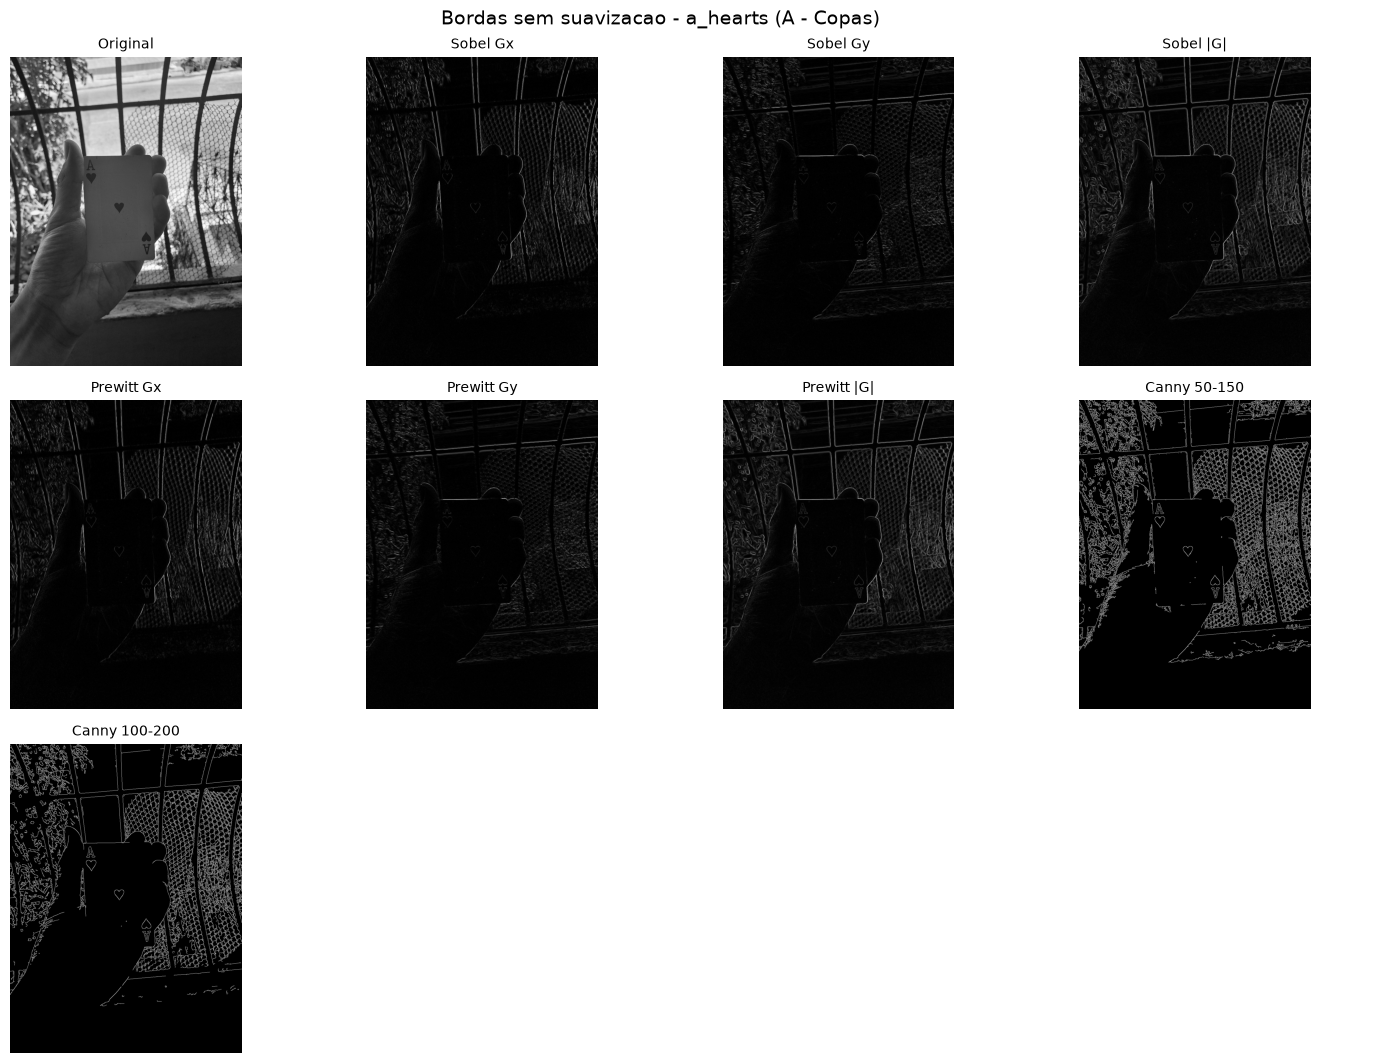

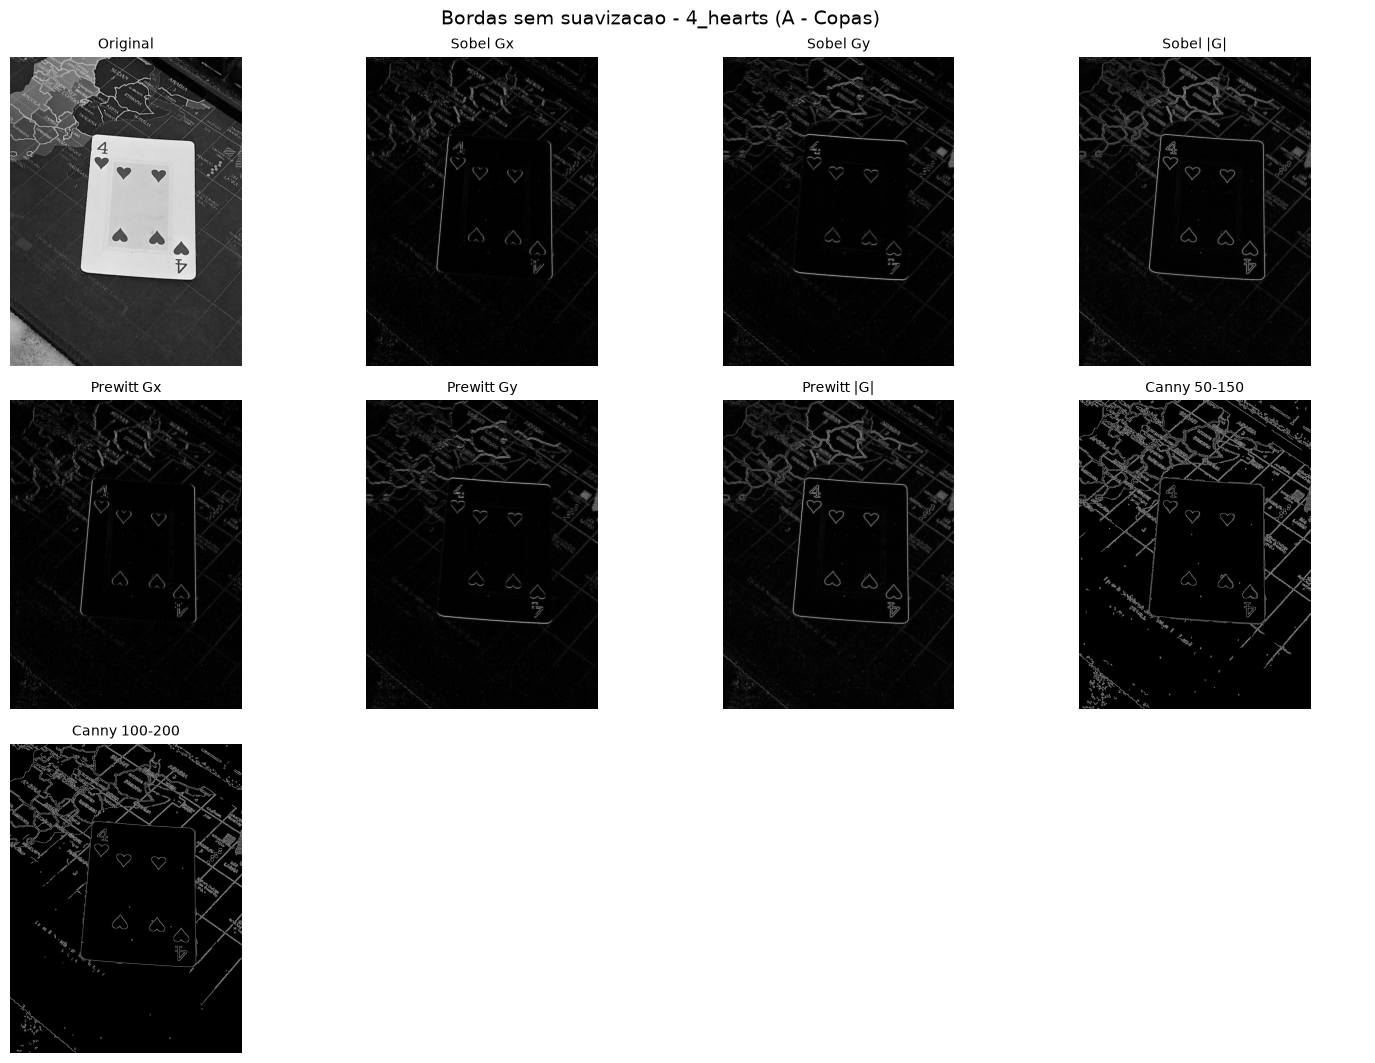

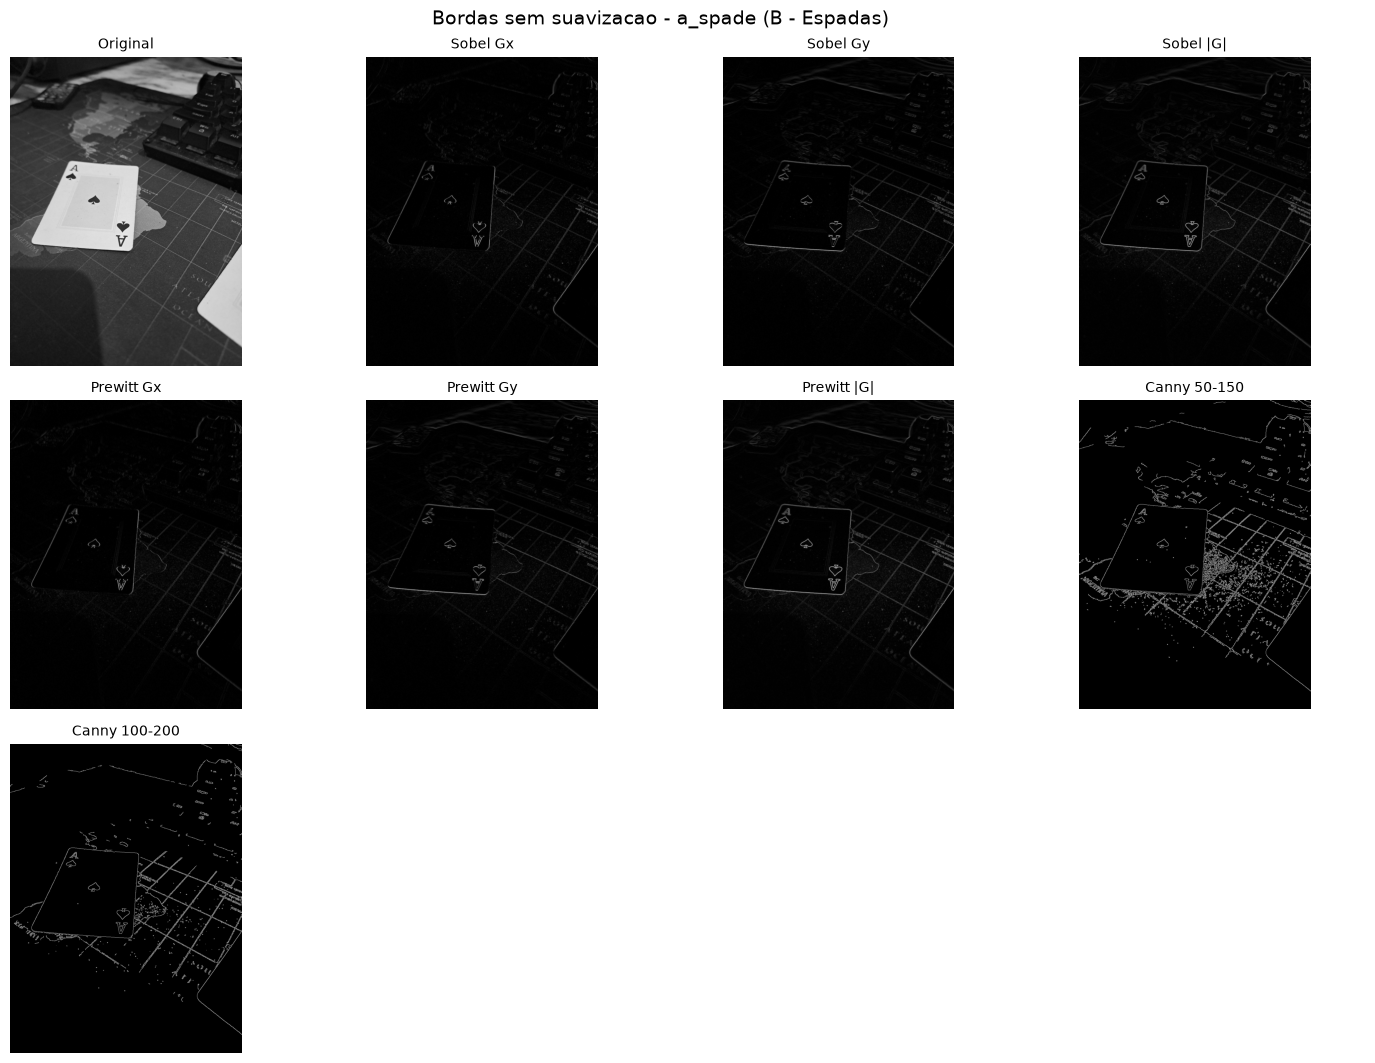

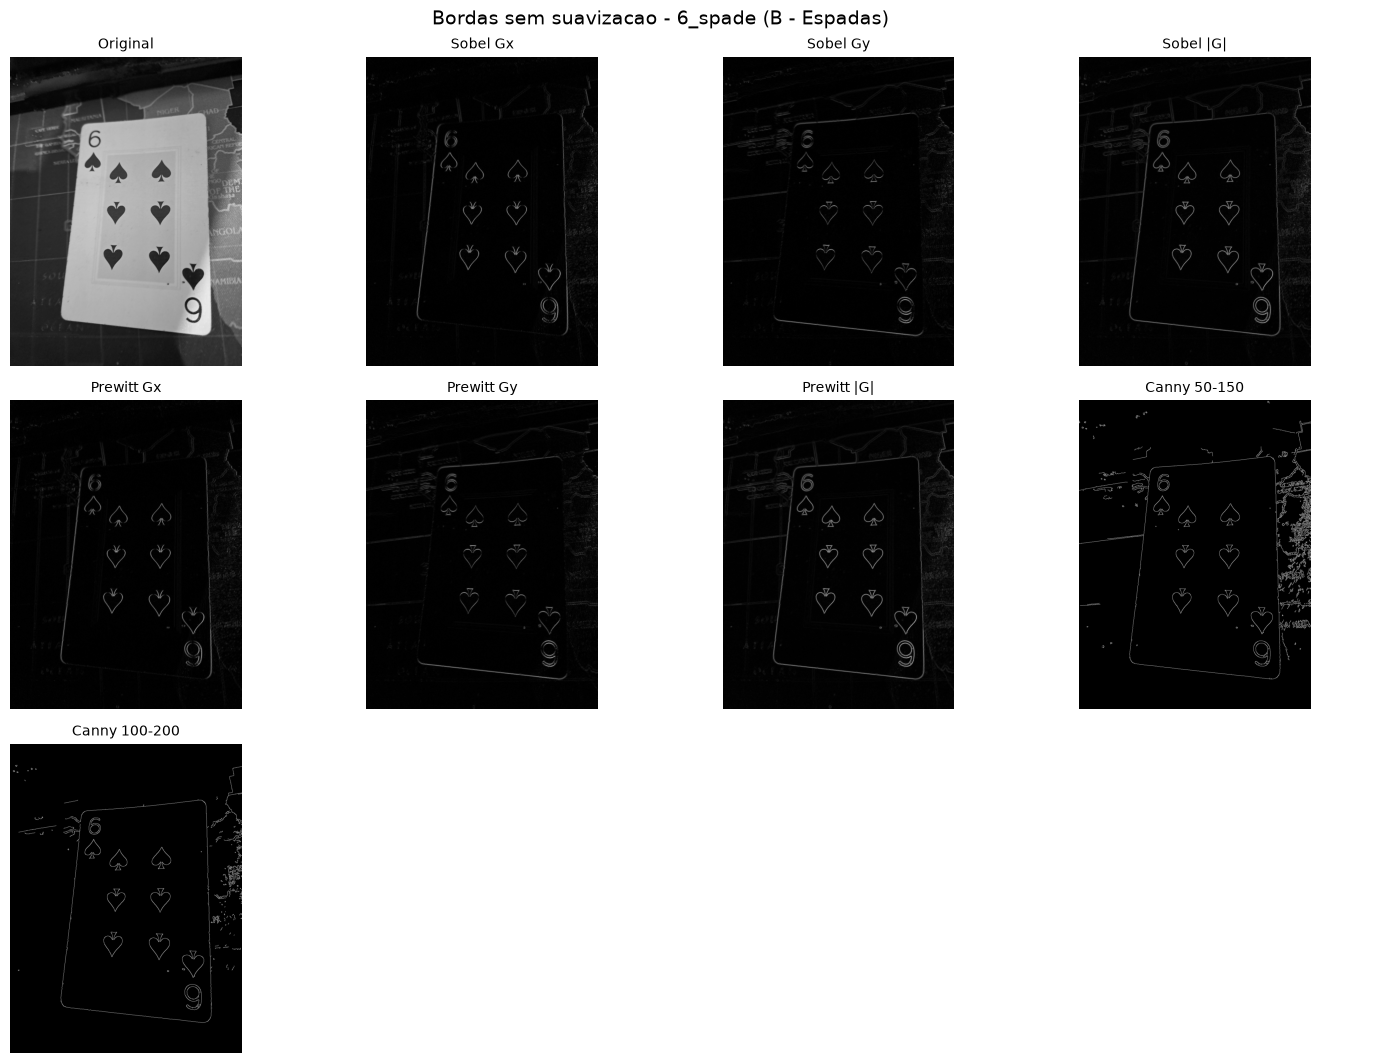

In [5]:
def sobel_edges(gray):
    gx = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
    gy = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)
    mag = cv2.magnitude(gx, gy)
    return gx, gy, mag


PREWITT_X = np.array([[-1, 0, 1], [-1, 0, 1], [-1, 0, 1]], dtype=np.float32)
PREWITT_Y = np.array([[-1, -1, -1], [0, 0, 0], [1, 1, 1]], dtype=np.float32)


def prewitt_edges(gray):
    gray_f = gray.astype(np.float32)
    gx = cv2.filter2D(gray_f, -1, PREWITT_X)
    gy = cv2.filter2D(gray_f, -1, PREWITT_Y)
    mag = cv2.magnitude(gx, gy)
    return gx, gy, mag


CANNY_THRESHOLDS = [(50, 150), (100, 200)]


def run_edge_detectors(gray):
    """Roda Sobel, Prewitt e Canny (varios limiares) e retorna (imagens_para_display, densidades)."""
    sx, sy, smag = sobel_edges(gray)
    px, py, pmag = prewitt_edges(gray)
    canny_imgs = {f"Canny {lo}-{hi}": cv2.Canny(gray, lo, hi) for lo, hi in CANNY_THRESHOLDS}

    images = {
        "Original": gray,
        "Sobel Gx": normalize_u8(sx),
        "Sobel Gy": normalize_u8(sy),
        "Sobel |G|": normalize_u8(smag),
        "Prewitt Gx": normalize_u8(px),
        "Prewitt Gy": normalize_u8(py),
        "Prewitt |G|": normalize_u8(pmag),
        **canny_imgs,
    }

    density = {
        "Sobel": float(np.mean(smag > 50)),
        "Prewitt": float(np.mean(pmag > 50)),
    }
    for name, img in canny_imgs.items():
        density[name] = float(np.mean(img > 0))

    return images, density


edge_images_original = {}
edge_density_original = {}

for key, meta in SELECTED.items():
    images, density = run_edge_detectors(meta["gray"])
    edge_images_original[key] = images
    edge_density_original[key] = density

    show_grid(
        list(images.values()), list(images.keys()), cols=4,
        suptitle=f"Bordas sem suavizacao - {key} ({meta['classe']})",
    )


In [6]:
for key, meta in SELECTED.items():
    density = edge_density_original[key]
    linhas = "\n".join(f"| {n} | {v * 100:.2f}% |" for n, v in density.items())
    mais_denso = max(density, key=density.get)
    menos_denso = min(density, key=density.get)

    display(Markdown(f"""
### Densidade de bordas sem suavização — `{key}`

| Operador | % de pixels marcados como borda |
|---|---|
{linhas}

- Operador com **maior densidade de bordas**: `{mais_denso}` — em uma imagem com ruído de sensor,
  densidade muito alta costuma indicar **sensibilidade ao ruído**: o operador reage a variações de
  intensidade pixel a pixel que não correspondem a bordas reais da carta, gerando bordas falsas.
- Operador com **menor densidade**: `{menos_denso}` — mais conservador, com menor risco de bordas
  falsas, mas também maior risco de perder bordas reais sutis.
- Sobel e Prewitt usam kernels de diferenciação de primeira ordem muito parecidos (a diferença é que
  Sobel dá peso 2 à linha/coluna central e Prewitt pesa tudo igual); por isso os resultados costumam
  ser próximos, com Sobel geralmente um pouco mais robusto ao ruído.
- Canny inclui suavização Gaussiana interna, supressão de não-máximos e limiar com histerese, por
  isso tende a produzir bordas mais finas e contínuas que Sobel/Prewitt brutos — mas sua sensibilidade
  ao ruído depende fortemente dos limiares escolhidos (limiares baixos → mais bordas falsas).
"""))



### Densidade de bordas sem suavização — `a_hearts`

| Operador | % de pixels marcados como borda |
|---|---|
| Sobel | 27.77% |
| Prewitt | 22.25% |
| Canny 50-150 | 8.66% |
| Canny 100-200 | 6.60% |

- Operador com **maior densidade de bordas**: `Sobel` — em uma imagem com ruído de sensor,
  densidade muito alta costuma indicar **sensibilidade ao ruído**: o operador reage a variações de
  intensidade pixel a pixel que não correspondem a bordas reais da carta, gerando bordas falsas.
- Operador com **menor densidade**: `Canny 100-200` — mais conservador, com menor risco de bordas
  falsas, mas também maior risco de perder bordas reais sutis.
- Sobel e Prewitt usam kernels de diferenciação de primeira ordem muito parecidos (a diferença é que
  Sobel dá peso 2 à linha/coluna central e Prewitt pesa tudo igual); por isso os resultados costumam
  ser próximos, com Sobel geralmente um pouco mais robusto ao ruído.
- Canny inclui suavização Gaussiana interna, supressão de não-máximos e limiar com histerese, por
  isso tende a produzir bordas mais finas e contínuas que Sobel/Prewitt brutos — mas sua sensibilidade
  ao ruído depende fortemente dos limiares escolhidos (limiares baixos → mais bordas falsas).



### Densidade de bordas sem suavização — `4_hearts`

| Operador | % de pixels marcados como borda |
|---|---|
| Sobel | 15.27% |
| Prewitt | 12.21% |
| Canny 50-150 | 5.44% |
| Canny 100-200 | 4.27% |

- Operador com **maior densidade de bordas**: `Sobel` — em uma imagem com ruído de sensor,
  densidade muito alta costuma indicar **sensibilidade ao ruído**: o operador reage a variações de
  intensidade pixel a pixel que não correspondem a bordas reais da carta, gerando bordas falsas.
- Operador com **menor densidade**: `Canny 100-200` — mais conservador, com menor risco de bordas
  falsas, mas também maior risco de perder bordas reais sutis.
- Sobel e Prewitt usam kernels de diferenciação de primeira ordem muito parecidos (a diferença é que
  Sobel dá peso 2 à linha/coluna central e Prewitt pesa tudo igual); por isso os resultados costumam
  ser próximos, com Sobel geralmente um pouco mais robusto ao ruído.
- Canny inclui suavização Gaussiana interna, supressão de não-máximos e limiar com histerese, por
  isso tende a produzir bordas mais finas e contínuas que Sobel/Prewitt brutos — mas sua sensibilidade
  ao ruído depende fortemente dos limiares escolhidos (limiares baixos → mais bordas falsas).



### Densidade de bordas sem suavização — `a_spade`

| Operador | % de pixels marcados como borda |
|---|---|
| Sobel | 11.07% |
| Prewitt | 7.25% |
| Canny 50-150 | 3.28% |
| Canny 100-200 | 1.84% |

- Operador com **maior densidade de bordas**: `Sobel` — em uma imagem com ruído de sensor,
  densidade muito alta costuma indicar **sensibilidade ao ruído**: o operador reage a variações de
  intensidade pixel a pixel que não correspondem a bordas reais da carta, gerando bordas falsas.
- Operador com **menor densidade**: `Canny 100-200` — mais conservador, com menor risco de bordas
  falsas, mas também maior risco de perder bordas reais sutis.
- Sobel e Prewitt usam kernels de diferenciação de primeira ordem muito parecidos (a diferença é que
  Sobel dá peso 2 à linha/coluna central e Prewitt pesa tudo igual); por isso os resultados costumam
  ser próximos, com Sobel geralmente um pouco mais robusto ao ruído.
- Canny inclui suavização Gaussiana interna, supressão de não-máximos e limiar com histerese, por
  isso tende a produzir bordas mais finas e contínuas que Sobel/Prewitt brutos — mas sua sensibilidade
  ao ruído depende fortemente dos limiares escolhidos (limiares baixos → mais bordas falsas).



### Densidade de bordas sem suavização — `6_spade`

| Operador | % de pixels marcados como borda |
|---|---|
| Sobel | 7.29% |
| Prewitt | 5.11% |
| Canny 50-150 | 1.91% |
| Canny 100-200 | 1.05% |

- Operador com **maior densidade de bordas**: `Sobel` — em uma imagem com ruído de sensor,
  densidade muito alta costuma indicar **sensibilidade ao ruído**: o operador reage a variações de
  intensidade pixel a pixel que não correspondem a bordas reais da carta, gerando bordas falsas.
- Operador com **menor densidade**: `Canny 100-200` — mais conservador, com menor risco de bordas
  falsas, mas também maior risco de perder bordas reais sutis.
- Sobel e Prewitt usam kernels de diferenciação de primeira ordem muito parecidos (a diferença é que
  Sobel dá peso 2 à linha/coluna central e Prewitt pesa tudo igual); por isso os resultados costumam
  ser próximos, com Sobel geralmente um pouco mais robusto ao ruído.
- Canny inclui suavização Gaussiana interna, supressão de não-máximos e limiar com histerese, por
  isso tende a produzir bordas mais finas e contínuas que Sobel/Prewitt brutos — mas sua sensibilidade
  ao ruído depende fortemente dos limiares escolhidos (limiares baixos → mais bordas falsas).


## Parte 4 — Detecção de Bordas após Suavização

### 1. Escolha do filtro de suavização

O filtro mais adequado é escolhido automaticamente a partir das métricas calculadas na Parte 2,
combinando redução de ruído **e** preservação de bordas em um único score:

`score = redução_de_variância × (energia_de_borda_pós_filtro / energia_de_borda_original)`

Um score alto exige as duas coisas ao mesmo tempo — reduzir ruído sem borrar demais as bordas — o que
é exatamente o critério discutido teoricamente na Parte 2 (mediana tende a se sair bem nesse
equilíbrio por ser um filtro não linear, robusto a ruído impulsivo, ao contrário da média/Gaussiano
que são lineares).

In [7]:
filter_names = list(next(iter(smoothing_results.values())).keys())
avg_scores = {name: [] for name in filter_names}

for key, meta in SELECTED.items():
    var_orig = meta["var_original"]
    edge_energy_orig = laplacian_energy(meta["gray"])
    stats = smoothing_results[key]
    for name in filter_names:
        reducao = (var_orig - stats[name]["var"]) / var_orig
        preservacao = stats[name]["edge_energy"] / edge_energy_orig
        avg_scores[name].append(reducao * preservacao)

avg_scores = {name: float(np.mean(v)) for name, v in avg_scores.items()}
BEST_FILTER = max(avg_scores, key=avg_scores.get)

linhas = "\n".join(
    f"| {n} | {v:.3f} |" for n, v in sorted(avg_scores.items(), key=lambda x: -x[1])
)

display(Markdown(f"""
| Filtro | Score médio (redução de ruído x preservação de bordas) |
|---|---|
{linhas}

**Filtro escolhido para a Parte 4: `{BEST_FILTER}`**
"""))



| Filtro | Score médio (redução de ruído x preservação de bordas) |
|---|---|
| Mediana 5x5 | 0.005 |
| Mediana 3x3 | 0.003 |
| Media 3x3 | 0.002 |
| Gaussiano sigma=1 | 0.002 |
| Media 5x5 | 0.002 |
| Gaussiano sigma=3 | 0.001 |

**Filtro escolhido para a Parte 4: `Mediana 5x5`**


### 2 e 3. Aplicar o filtro escolhido e reaplicar Sobel, Prewitt e Canny

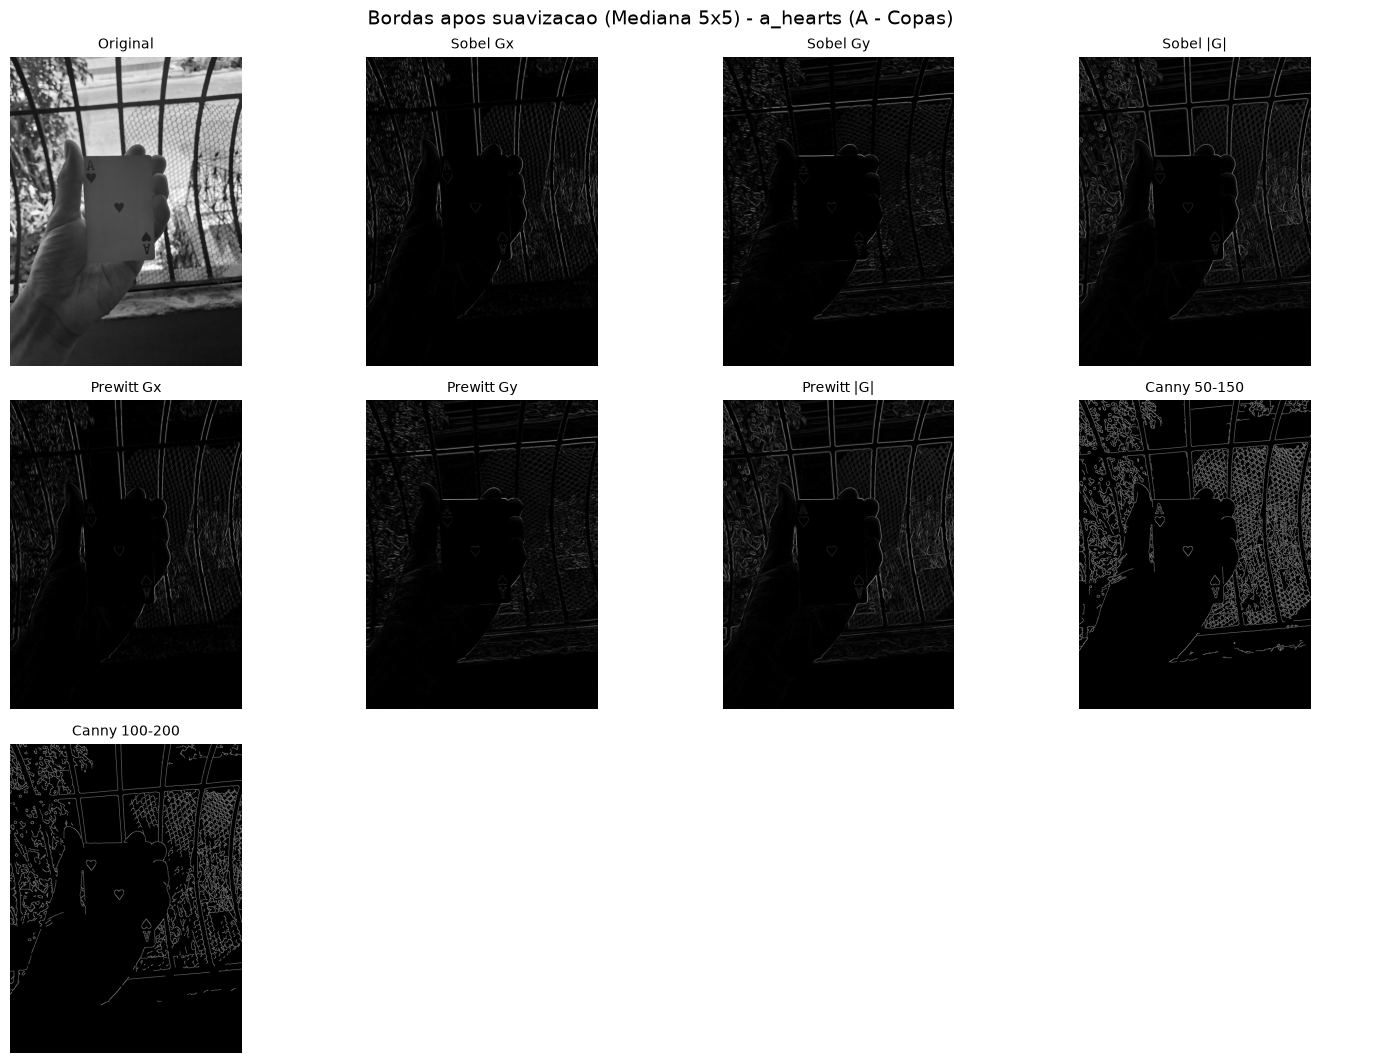

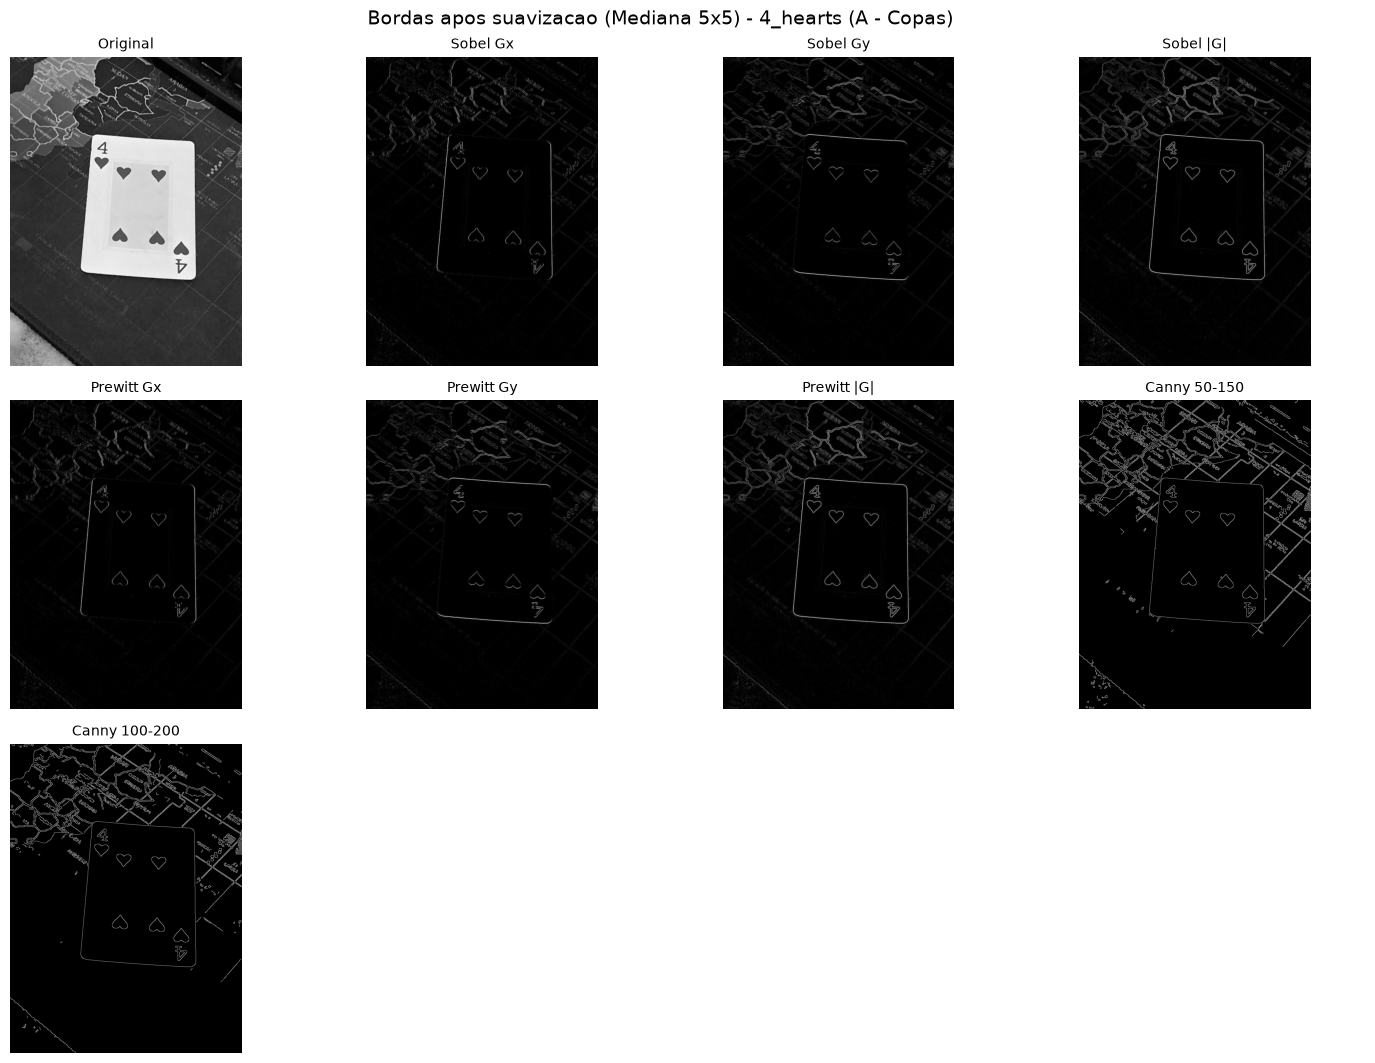

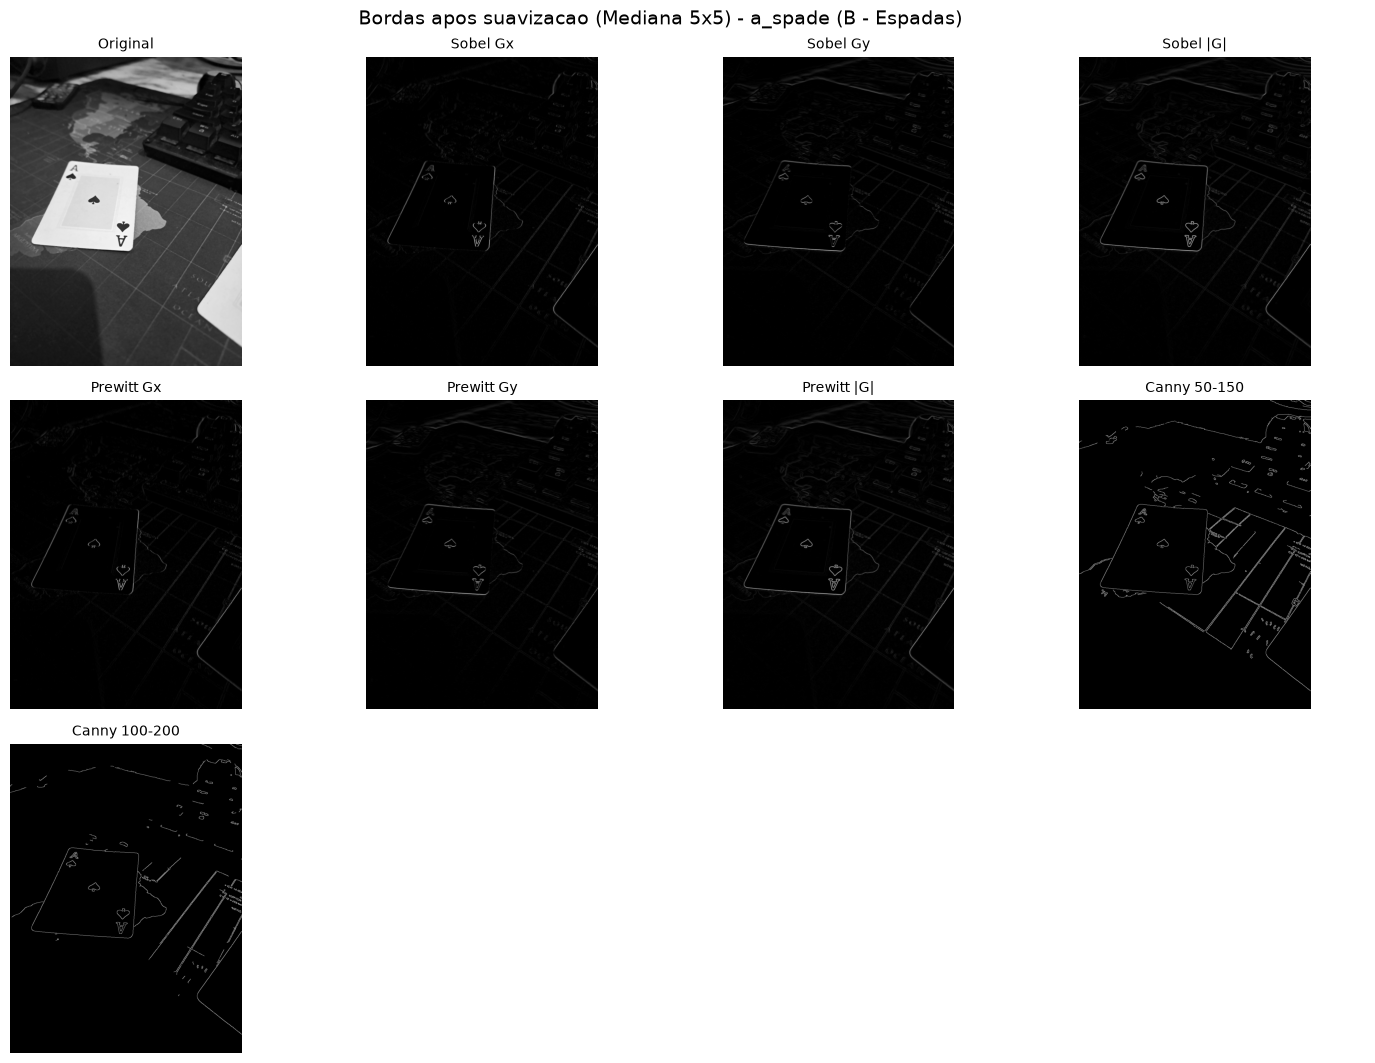

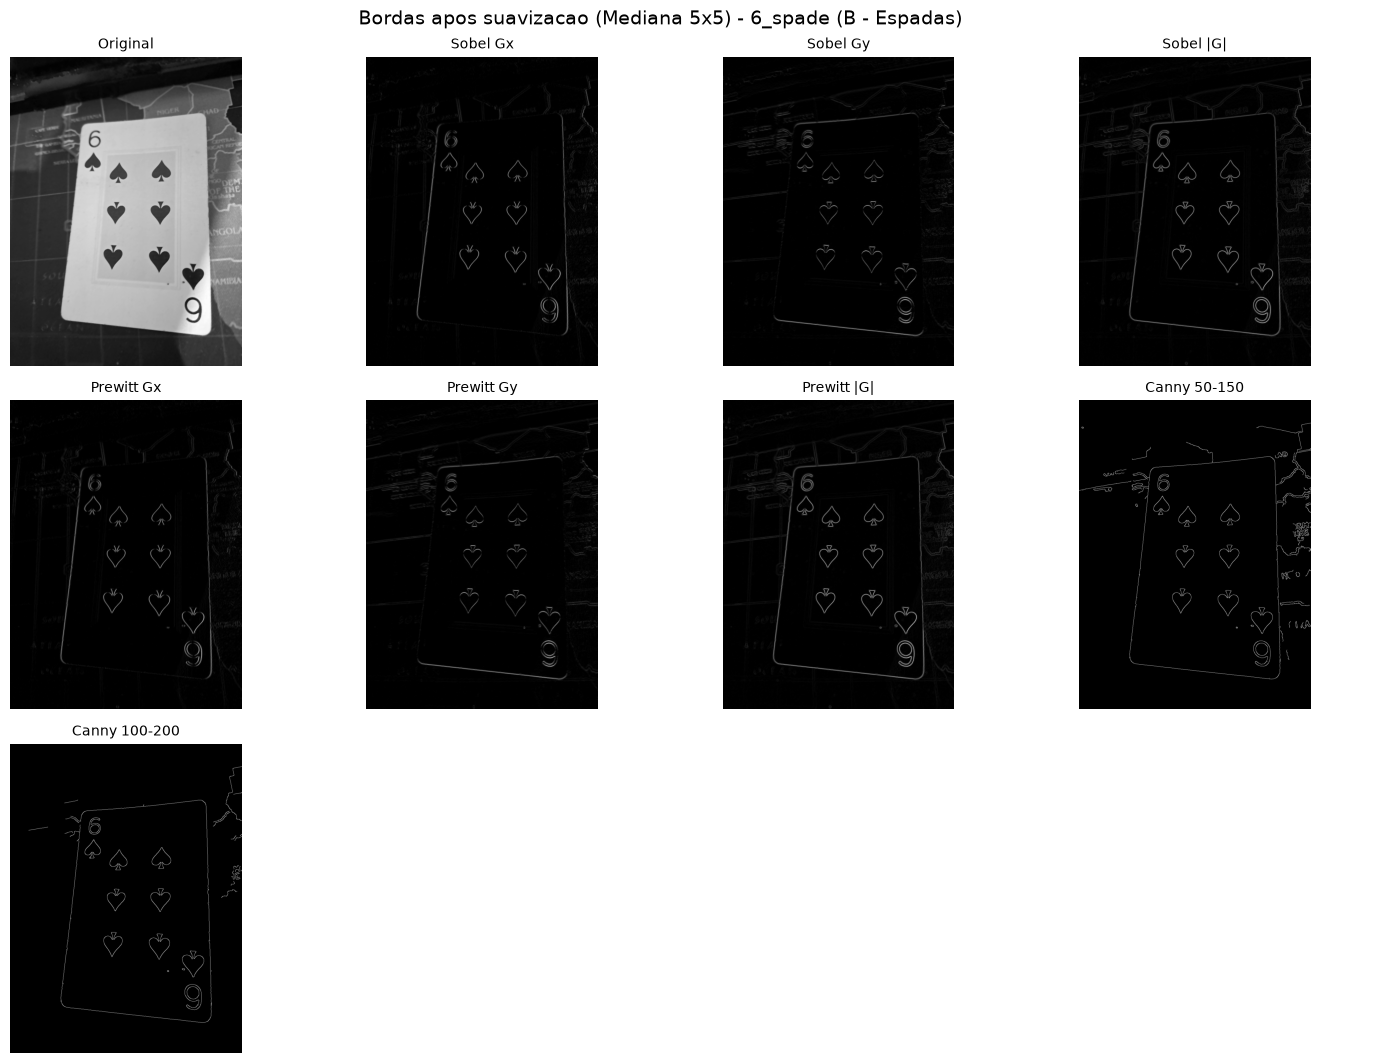

In [8]:
edge_images_smoothed = {}
edge_density_smoothed = {}

for key, meta in SELECTED.items():
    smoothed_gray = smoothing_results[key][BEST_FILTER]["img"]
    images, density = run_edge_detectors(smoothed_gray)
    edge_images_smoothed[key] = images
    edge_density_smoothed[key] = density

    show_grid(
        list(images.values()), list(images.keys()), cols=4,
        suptitle=f"Bordas apos suavizacao ({BEST_FILTER}) - {key} ({meta['classe']})",
    )


### Comparação: quantidade de bordas, redução de bordas falsas e robustez ao ruído

- **Quantidade de bordas detectadas** — comparamos a densidade de bordas antes/depois da suavização
  para cada operador.
- **Redução de bordas falsas** — quando a densidade cai após a suavização sem que a imagem perca
  estrutura reconhecível da carta (o que já observamos visualmente nas grades acima), isso é
  evidência de remoção de bordas falsas geradas por ruído.
- **Robustez ao ruído** — operadores mais robustos variam pouco entre a versão ruidosa (Parte 3) e a
  versão suavizada (Parte 4); operadores sensíveis ao ruído mudam bastante.

In [9]:
comparacao_rows = []
robustez_por_operador = {}

for key, meta in SELECTED.items():
    antes = edge_density_original[key]
    depois = edge_density_smoothed[key]
    for operador in antes:
        d_antes = antes[operador]
        d_depois = depois[operador]
        variacao_pct = 100 * (d_antes - d_depois) / d_antes if d_antes > 0 else 0.0
        comparacao_rows.append((key, operador, d_antes, d_depois, variacao_pct))
        robustez_por_operador.setdefault(operador, []).append(abs(variacao_pct))

linhas = "\n".join(
    f"| {k} | {op} | {a * 100:.2f}% | {d * 100:.2f}% | {v:+.1f}% |"
    for k, op, a, d, v in comparacao_rows
)

robustez_media = {op: float(np.mean(v)) for op, v in robustez_por_operador.items()}
mais_robusto = min(robustez_media, key=robustez_media.get)
menos_robusto = max(robustez_media, key=robustez_media.get)

display(Markdown(f"""
| Imagem | Operador | Densidade antes | Densidade depois | Redução de bordas |
|---|---|---|---|---|
{linhas}

**Variação média de densidade por operador (menor = mais robusto ao ruído, pois muda pouco com ou
sem suavização prévia):**

{chr(10).join(f"- `{op}`: {v:.1f}%" for op, v in sorted(robustez_media.items(), key=lambda x: x[1]))}

- **Operador mais robusto ao ruído nesta comparação: `{mais_robusto}`**
- **Operador mais sensível ao ruído nesta comparação: `{menos_robusto}`**
"""))



| Imagem | Operador | Densidade antes | Densidade depois | Redução de bordas |
|---|---|---|---|---|
| a_hearts | Sobel | 27.77% | 22.23% | +19.9% |
| a_hearts | Prewitt | 22.25% | 16.98% | +23.7% |
| a_hearts | Canny 50-150 | 8.66% | 6.31% | +27.1% |
| a_hearts | Canny 100-200 | 6.60% | 4.14% | +37.3% |
| 4_hearts | Sobel | 15.27% | 9.92% | +35.0% |
| 4_hearts | Prewitt | 12.21% | 8.02% | +34.3% |
| 4_hearts | Canny 50-150 | 5.44% | 3.91% | +28.2% |
| 4_hearts | Canny 100-200 | 4.27% | 2.88% | +32.5% |
| a_spade | Sobel | 11.07% | 5.86% | +47.0% |
| a_spade | Prewitt | 7.25% | 3.98% | +45.1% |
| a_spade | Canny 50-150 | 3.28% | 1.54% | +53.0% |
| a_spade | Canny 100-200 | 1.84% | 0.95% | +48.2% |
| 6_spade | Sobel | 7.29% | 5.12% | +29.8% |
| 6_spade | Prewitt | 5.11% | 3.78% | +26.0% |
| 6_spade | Canny 50-150 | 1.91% | 1.13% | +40.6% |
| 6_spade | Canny 100-200 | 1.05% | 0.77% | +27.0% |

**Variação média de densidade por operador (menor = mais robusto ao ruído, pois muda pouco com ou
sem suavização prévia):**

- `Prewitt`: 32.3%
- `Sobel`: 33.0%
- `Canny 100-200`: 36.2%
- `Canny 50-150`: 37.2%

- **Operador mais robusto ao ruído nesta comparação: `Prewitt`**
- **Operador mais sensível ao ruído nesta comparação: `Canny 50-150`**


### Síntese — Parte 4

**A suavização melhorou a detecção?** Em geral sim: como discutido na Parte 2, o filtro escolhido
(`BEST_FILTER`, calculado acima) reduz variância mantendo boa parte da energia de borda; ao remover
grão de alta frequência antes da diferenciação, os operadores de borda deixam de reagir a cada pixel
ruidoso isolado, reduzindo a densidade de bordas espúrias (visível na tabela de comparação) sem
apagar os contornos reais da carta e do naipe, que têm suporte espacial maior que o ruído.

**Qual operador foi mais robusto ao ruído?** Pela tabela acima, o operador com menor variação média
de densidade entre a versão com ruído (Parte 3) e a versão suavizada (Parte 4) é o mais robusto —
teoricamente esperado ser o Canny, já que ele já incorpora suavização Gaussiana e supressão de
não-máximos internamente, tornando-o menos dependente de um pré-processamento externo.

**Qual apresentou melhor definição estrutural?** Sobel e Prewitt (mesmo após suavização) produzem
bordas relativamente grossas, pois são operadores de gradiente puro sem afinamento; Canny, por
aplicar supressão de não-máximos e histerese, produz contornos finos (1 pixel) e mais contínuos ao
longo do naipe/número da carta, sendo estruturalmente o mais bem definido dos três.

## Conclusão / Relatório final

In [10]:
if "Mediana" in BEST_FILTER:
    justificativa_best_filter = (
        "é um filtro não linear baseado em estatística de ordem, o que o torna especialmente eficaz "
        "contra ruído impulsivo/granulação isolada sem borrar tanto os contornos do naipe/número."
    )
elif "Gaussiano" in BEST_FILTER:
    justificativa_best_filter = (
        "pondera os vizinhos pela distância ao centro (peso decrescente), suavizando o ruído de forma "
        "mais controlada que uma média simples e preservando melhor as transições de borda."
    )
else:
    justificativa_best_filter = (
        "obteve o melhor equilíbrio entre redução de variância e energia de borda entre os filtros "
        "lineares testados neste dataset."
    )

display(Markdown(f"""
### Relatório consolidado do pipeline

**Dataset:** 4 imagens do mini dataset de cartas (2 de Copas, 2 de Espadas), todas fotografadas com
Samsung Galaxy A33, selecionadas por apresentarem ruído/granulação de sensor ligado a baixa luz
(`4_hearts`, `a_spade`, `6_spade`) ou a alto contraste/contraluz (`a_hearts`).

**Suavização (Parte 2):** entre Média, Gaussiano e Mediana (kernels 3x3/5x5, σ=1/σ=3), o filtro
escolhido pelo critério objetivo (redução de variância x preservação de energia de borda) foi
**`{BEST_FILTER}`**, com score médio de **{avg_scores[BEST_FILTER]:.3f}** — o melhor equilíbrio entre
remover o grão do sensor e não destruir os contornos do naipe/número. Kernels maiores sempre reduziram
mais a variância, mas às custas de mais energia de borda perdida, confirmando o trade-off clássico
entre tamanho de kernel e preservação de detalhe.

**Bordas sem suavização (Parte 3):** Sobel, Prewitt e Canny (limiares {CANNY_THRESHOLDS}) aplicados
direto na imagem ruidosa mostraram densidades de borda mais altas, com padrão espalhado ("salpicado")
nas regiões de fundo com mais grão — sinal de bordas falsas geradas pelo ruído, mais evidentes nas
imagens de baixa luz (`a_spade`, `6_spade`, `4_hearts`).

**Bordas após suavização (Parte 4):** reaplicando os três operadores sobre a imagem filtrada com
`{BEST_FILTER}`, a densidade de bordas caiu na maioria dos casos, indicando remoção de bordas falsas,
com o operador **`{mais_robusto}`** variando menos entre as versões com e sem suavização — a robustez
ao ruído esperada pela teoria.

**Conclusão geral:** para este dataset, cuja principal degradação é ruído de sensor associado a baixa
luminância, o filtro `{BEST_FILTER}` se destacou porque {justificativa_best_filter} A suavização
prévia se mostra uma etapa de pré-processamento relevante antes da detecção de bordas, reduzindo
falsos positivos que poderiam prejudicar etapas posteriores de segmentação/classificação do naipe da
carta.
"""))



### Relatório consolidado do pipeline

**Dataset:** 4 imagens do mini dataset de cartas (2 de Copas, 2 de Espadas), todas fotografadas com
Samsung Galaxy A33, selecionadas por apresentarem ruído/granulação de sensor ligado a baixa luz
(`4_hearts`, `a_spade`, `6_spade`) ou a alto contraste/contraluz (`a_hearts`).

**Suavização (Parte 2):** entre Média, Gaussiano e Mediana (kernels 3x3/5x5, σ=1/σ=3), o filtro
escolhido pelo critério objetivo (redução de variância x preservação de energia de borda) foi
**`Mediana 5x5`**, com score médio de **0.005** — o melhor equilíbrio entre
remover o grão do sensor e não destruir os contornos do naipe/número. Kernels maiores sempre reduziram
mais a variância, mas às custas de mais energia de borda perdida, confirmando o trade-off clássico
entre tamanho de kernel e preservação de detalhe.

**Bordas sem suavização (Parte 3):** Sobel, Prewitt e Canny (limiares [(50, 150), (100, 200)]) aplicados
direto na imagem ruidosa mostraram densidades de borda mais altas, com padrão espalhado ("salpicado")
nas regiões de fundo com mais grão — sinal de bordas falsas geradas pelo ruído, mais evidentes nas
imagens de baixa luz (`a_spade`, `6_spade`, `4_hearts`).

**Bordas após suavização (Parte 4):** reaplicando os três operadores sobre a imagem filtrada com
`Mediana 5x5`, a densidade de bordas caiu na maioria dos casos, indicando remoção de bordas falsas,
com o operador **`Prewitt`** variando menos entre as versões com e sem suavização — a robustez
ao ruído esperada pela teoria.

**Conclusão geral:** para este dataset, cuja principal degradação é ruído de sensor associado a baixa
luminância, o filtro `Mediana 5x5` se destacou porque é um filtro não linear baseado em estatística de ordem, o que o torna especialmente eficaz contra ruído impulsivo/granulação isolada sem borrar tanto os contornos do naipe/número. A suavização
prévia se mostra uma etapa de pré-processamento relevante antes da detecção de bordas, reduzindo
falsos positivos que poderiam prejudicar etapas posteriores de segmentação/classificação do naipe da
carta.
